# Cours "Méthodes Quantitatives en Histoire" - Visualisation de Données Historiques
### Louis Maritaud
### louis.maritaud@unilim.fr

## Objectifs pédagogiques
- Comprendre la philosophie de construction d'un graphique en Python appliqué aux séries historiques
- Maîtriser l'architecture Figure/Axes de Matplotlib pour comparer des périodes ou des zones géographiques
- Appliquer les règles de la sémiologie graphique aux données du passé (chronologies, effectifs, catégories)
- Manipuler la bibliothèque Seaborn pour explorer rapidement des bases de données d'archives (registres, inventaires)
- Apprendre à discrétiser des données quantitatives continues (ex: âges, taxes) en catégories historiques porteuses de sens

## Partie 1 : Fondations de la visualisation avec Matplotlib

### 1. L'architecture Orientée Objet de Matplotlib
Pour construire des graphiques rigoureux destinés à vos publications ou mémoires, on définit presque toujours **deux objets** :
- La **Figure (`fig`)** : c'est l'espace global, votre planche de travail ou la page blanche qui contient le ou les graphiques.
- L'**Axe (`ax`)** : c'est la zone de tracé spécifique (contenant l'axe chronologique X, l'axe des effectifs Y, les titres, etc.).

In [31]:
# Installation (si nécessaire)
# !pip install matplotlib seaborn pandas numpy

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# Jeu de données : Évolution estimée de la population de deux grandes villes de l'Ouest de la France (en milliers d'habitants)
df = pd.read_csv("DATA/pop_historique.csv", encoding="utf-8", sep=";", skiprows=1)
df.dropna(subset=["DEP"], inplace=True)
df["DEP"]=df["DEP"].astype(str).str.replace(".0", "")
df["REG"]=df["REG"].astype(str).str.replace(".0", "")
df["CODGEO"]=df["CODGEO"].astype(str).str.replace(".0", "")
# Affichage du tableau de données

df.to_csv("pop_hist.csv", sep=",", encoding="utf-8", index=False)
display(df)
data_villes = df[ (df["LIBGEO"]=="Limoges") | (df["LIBGEO"]=="Bordeaux") ]
display(data_villes)

df = data_villes
# 2. L'opération magique : on sépare les identifiants des colonnes d'années
colonnes_identifiants = ['CODGEO', 'REG', 'DEP', 'LIBGEO']

df_long = df.melt(
    id_vars=colonnes_identifiants,       # Les colonnes à garder intactes
    var_name='Annee_Brute',              # Le nom de la future colonne contenant les ex-en-têtes (ex: PMUN2023)
    value_name='Population'              # Le nom de la colonne contenant les valeurs numériques
)

# 3. Nettoyage historique : on extrait uniquement les 4 chiffres de l'année
# (Cela enlève 'PMUN' ou 'PTOT' pour ne garder que l'année propre)
df_long['Annee'] = df_long['Annee_Brute'].str.extract(r'(\d{4})').astype(int)

# On supprime la colonne brute devenue inutile et on trie par ville et chronologie
df_long = df_long.drop(columns=['Annee_Brute']).sort_values(by=['LIBGEO', 'Annee'])
df_long['Population'] = df_long['Population'].astype(str).str.replace(r'\s+', '', regex=True)
df_long['Population'] = pd.to_numeric(df_long['Population'], errors='coerce')
# Regardons le résultat
display(df_long)

C:\Users\maritp02\AppData\Local\Temp\ipykernel_24480\3848625303.py:10: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("DATA/pop_historique.csv", encoding="utf-8", sep=";", skiprows=1)


,CODGEO,REG,DEP,LIBGEO,PMUN2023,PMUN2022,PMUN2021,PMUN2020,PMUN2019,PMUN2018,...,PTOT1926,PTOT1921,PTOT1911,PTOT1906,PTOT1901,PTOT1896,PTOT1891,PTOT1886,PTOT1881,PTOT1876
0,01001,84,01,L'Abergement-Clémenciat,860,859,832,806,779,771,...,543,566,560,629,637,572,594,622,605,604
1,01002,84,01,L'Abergement-de-Varey,270,273,267,262,256,253,...,253,256,291,323,357,391,421,486,490,484
2,01004,84,01,Ambérieu-en-Bugey,15 934,15 554,14 854,14 288,14 134,14 204,...,5 705,4 796,4 334,4 100,4 023,3 548,3 635,3 618,3 396,3 427
3,01005,84,01,Ambérieux-en-Dombes,1 906,1 917,1 897,1 782,1 751,1 720,...,690,698,805,805,835,852,862,882,879,848
4,01006,84,01,Ambléon,115,114,113,113,112,112,...,161,150,159,193,200,206,200,200,213,191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34872,97420,4,974,Sainte-Suzanne,25 551,24 855,24 293,24 086,24 065,23 718,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34873,97421,4,974,Salazie,7 268,7 333,7 243,7 310,7 136,7 224,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34874,97422,4,974,Le Tampon,82 579,81 964,81 943,80 778,79 824,79 385,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34875,97423,4,974,Les Trois-Bassins,7 221,7 113,6 899,6 953,7 015,7 076,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,CODGEO,REG,DEP,LIBGEO,PMUN2023,PMUN2022,PMUN2021,PMUN2020,PMUN2019,PMUN2018,...,PTOT1926,PTOT1921,PTOT1911,PTOT1906,PTOT1901,PTOT1896,PTOT1891,PTOT1886,PTOT1881,PTOT1876
12328,33063,75,33,Bordeaux,267 991,265 328,261 804,259 809,260 958,257 068,...,273 840,283 394,275 468,264 835,268 186,267 369,261 085,248 545,227 736,220 446
33122,87085,75,87,Limoges,129 937,129 754,129 760,130 592,130 876,131 479,...,98 964,90 911,92 973,89 348,84 884,78 461,73 470,69 207,64 442,59 672


,CODGEO,REG,DEP,LIBGEO,Population,Annee
72,33063,75,33,Bordeaux,220446,1876
70,33063,75,33,Bordeaux,227736,1881
68,33063,75,33,Bordeaux,248545,1886
66,33063,75,33,Bordeaux,261085,1891
64,33063,75,33,Bordeaux,267369,1896
...,...,...,...,...,...,...
9,87085,75,87,Limoges,130876,2019
7,87085,75,87,Limoges,130592,2020
5,87085,75,87,Limoges,129760,2021
3,87085,75,87,Limoges,129754,2022


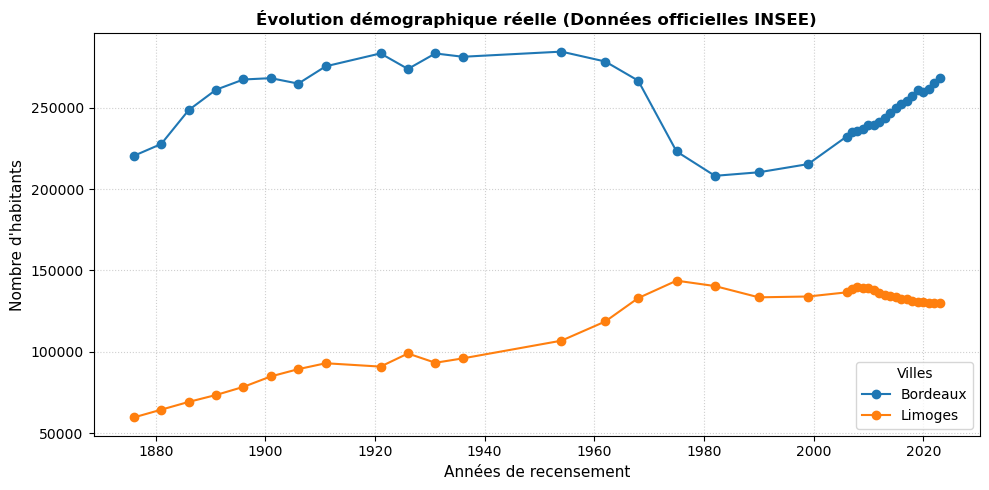

In [33]:
import matplotlib.pyplot as plt

# 1. On crée la figure et l'axe de travail
fig, ax = plt.subplots(figsize=(10, 5))

# 2. La boucle magique : on groupe le DataFrame par le nom des villes
# nom_ville sera le texte (ex: 'Bordeaux') et df_ville sera le sous-tableau de cette ville
for nom_ville, df_ville in df_long.groupby('LIBGEO'):
    
    # On trie par année pour être sûr que la ligne ne s'emmêle pas
    df_ville = df_ville.sort_values('Annee')
    
    # On trace la courbe de la ville actuelle
    ax.plot(
        df_ville['Annee'], 
        df_ville['Population'], 
        marker='o', 
        label=nom_ville  # L'étiquette pour la légende automatique
    )

# 3. Habillage académique
ax.set_title("Évolution démographique réelle (Données officielles INSEE)", fontsize=12, fontweight='bold')
ax.set_xlabel("Années de recensement", fontsize=11)
ax.set_ylabel("Nombre d'habitants", fontsize=11)

# On affiche la légende (Matplotlib rassemble tous les 'label' de la boucle)
ax.legend(title="Villes")
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

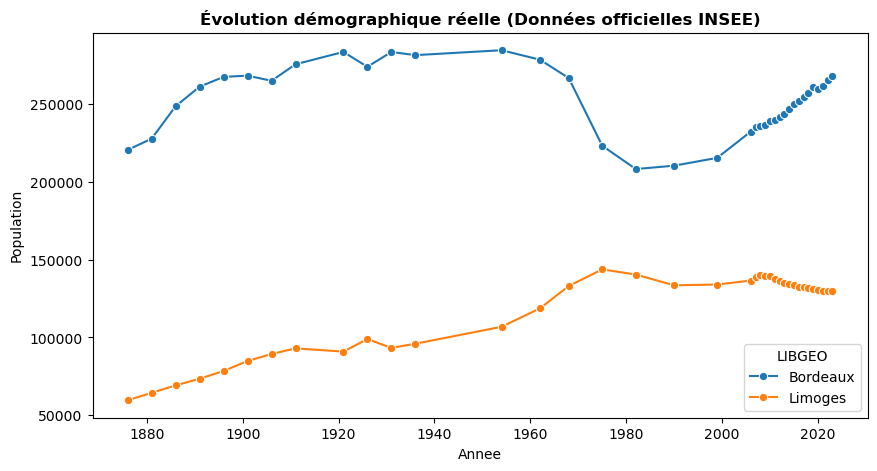

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Seaborn gère automatiquement les légendes et les couleurs grâce au format long !
sns.lineplot(data=df_long, x='Annee', y='Population', hue='LIBGEO', marker='o', ax=ax)

ax.set_title("Évolution démographique réelle (Données officielles INSEE)", fontsize=12, fontweight='bold')
plt.show()

### 2. Gestion de plusieurs sous-graphiques (Subplots)
Tout comme en cartographie historique où nous juxtaposons des cartes de différentes époques, nous pouvons croiser plusieurs types de graphiques pour analyser différentes facettes d'un même document d'archive.

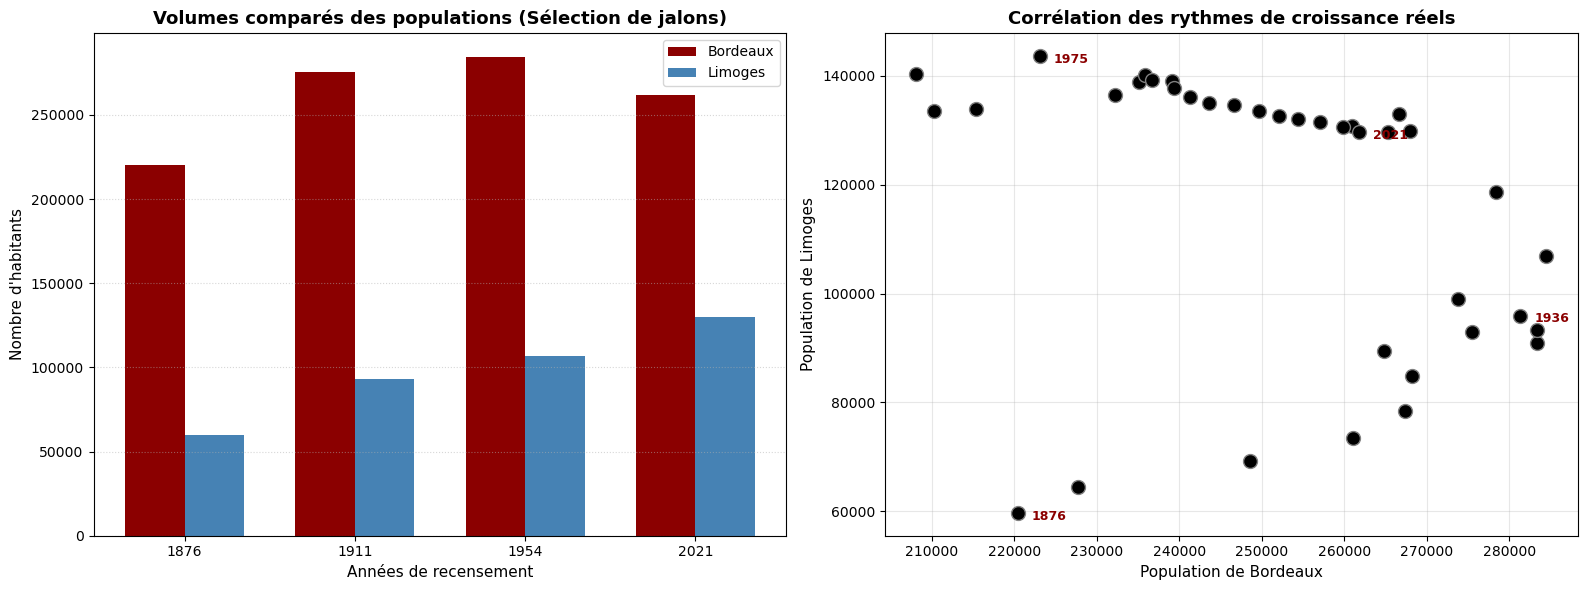

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Préparation des données pour le Graphique 1 (Barres juxtaposées)
# On sélectionne quelques jalons chronologiques pour ne pas surcharger les barres
annees_selectionnees = [1876, 1911, 1954, 2021]
df_filtre = df_long[df_long['Annee'].isin(annees_selectionnees)]

# On isole les données de nos deux villes pour ces années spécifiques
df_bordeaux_barres = df_filtre[df_filtre['LIBGEO'] == 'Bordeaux'].sort_values('Annee')
df_limoges_barres = df_filtre[df_filtre['LIBGEO'] == 'Limoges'].sort_values('Annee')


# 2. Préparation des données pour le Graphique 2 (Nuage de points)
# Pour corréler les trajectoires, il nous faut la population des deux villes face à face pour TOUTES les années communes
df_pivot = df_long.pivot(index='Annee', columns='LIBGEO', values='Population').dropna()


# 3. Construction de la figure (1 ligne, 2 colonnes)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 (Axe index 0) : Diagramme en barres comparatif ---
x = np.arange(len(annees_selectionnees))
largeur = 0.35

# Tracé des barres en utilisant les colonnes réelles du fichier
ax[0].bar(x - largeur/2, df_bordeaux_barres['Population'], largeur, label='Bordeaux', color='#8b0000')
ax[0].bar(x + largeur/2, df_limoges_barres['Population'], largeur, label='Limoges', color='#4682b4')

ax[0].set_title("Volumes comparés des populations (Sélection de jalons)", fontsize=13, fontweight='bold')
ax[0].set_xlabel("Années de recensement", fontsize=11)
ax[0].set_ylabel("Nombre d'habitants", fontsize=11)
ax[0].set_xticks(x)
ax[0].set_xticklabels(annees_selectionnees)
ax[0].grid(True, linestyle=':', alpha=0.5, axis='y') # Grille horizontale uniquement pour la lisibilité
ax[0].legend()


# --- Graphique 2 (Axe index 1) : Nuage de points (Corrélation) ---
# On croise la colonne 'Bordeaux' et la colonne 'Limoges' obtenues via le pivot
ax[1].scatter(df_pivot['Bordeaux'], df_pivot['Limoges'], color='black', s=100, edgecolor='grey', zorder=3)

ax[1].set_title("Corrélation des rythmes de croissance réels", fontsize=13, fontweight='bold')
ax[1].set_xlabel("Population de Bordeaux", fontsize=11)
ax[1].set_ylabel("Population de Limoges", fontsize=11)
ax[1].grid(True, alpha=0.3)

# Optionnel : Ajouter des étiquettes de dates sur quelques points du nuage pour l'analyse historique
for annee in [1876, 1936, 1975, 2021]:
    if annee in df_pivot.index:
        ax[1].annotate(
            str(annee), 
            (df_pivot.loc[annee, 'Bordeaux'], df_pivot.loc[annee, 'Limoges']),
            textcoords="offset points", 
            xytext=(10,-5), 
            ha='left', 
            fontsize=9, 
            fontweight='bold',
            color='darkred'
        )

plt.tight_layout()
plt.show()

# EXERCICE 1
À l'aide des données fournies ci-dessous (estimations du prix moyen du setier de blé à Paris et à Toulouse au cours du XVIIIe siècle), réalisez un graphique comprenant une figure et un axe.
Le graphique doit afficher une courbe rouge pour les prix parisiens et une courbe bleue pour les prix toulousains, avec des marqueurs pour chaque date, une grille de fond et une légende explicite pour analyser les crises de subsistance.

In [4]:
donnees_ble = {
    'Annee': ['1720', '1730', '1740', '1750', '1760', '1770', '1775', '1780', '1785', '1789'],
    'Prix_Paris': [15.2, 14.8, 19.5, 16.1, 18.3, 24.5, 28.2, 22.1, 23.8, 32.5], # Prix fictifs pour l'exercice
    'Prix_Toulouse': [12.1, 11.5, 16.2, 13.0, 14.8, 20.1, 23.4, 18.5, 19.2, 27.0]
}
df_ble = pd.DataFrame(donnees_ble)

# Votre code ici

## Partie 2 : Visualisation d'Archives et Statistique avec Seaborn

### 1. Pourquoi utiliser Seaborn en histoire ?
- **Adéquation avec les bases de données (DataFrames)** : Idéal pour traiter des listes de passagers, des registres paroissiaux ou des inventaires après décès.
- **Esthétique immédiate** : Des graphiques épurés de niveau publication scientifique sans passer des heures à configurer le code.
- **Modélisation visuelle** : Seaborn calcule de manière transparente des tendances historiques, des densités ou des répartitions catégorielles.

In [5]:
import seaborn as sns

# Application d'un thème Seaborn sobre adapté aux publications
sns.set_theme(style="ticks")

# On charge un jeu de données réel converti pour l'histoire sociale : un registre de pourboires/taxes payés par des clients
# Imaginons qu'il s'agisse d'un registre de comptes de taverne ou d'un grand hôtel de voyageurs du XIXe siècle
df_registre = sns.load_dataset('tips')

print("Aperçu des lignes de notre registre comptable (Montant total, taxe, genre du payeur, jour, moment) :")
display(df_registre.head())

Aperçu des lignes de notre registre comptable (Montant total, taxe, genre du payeur, jour, moment) :


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


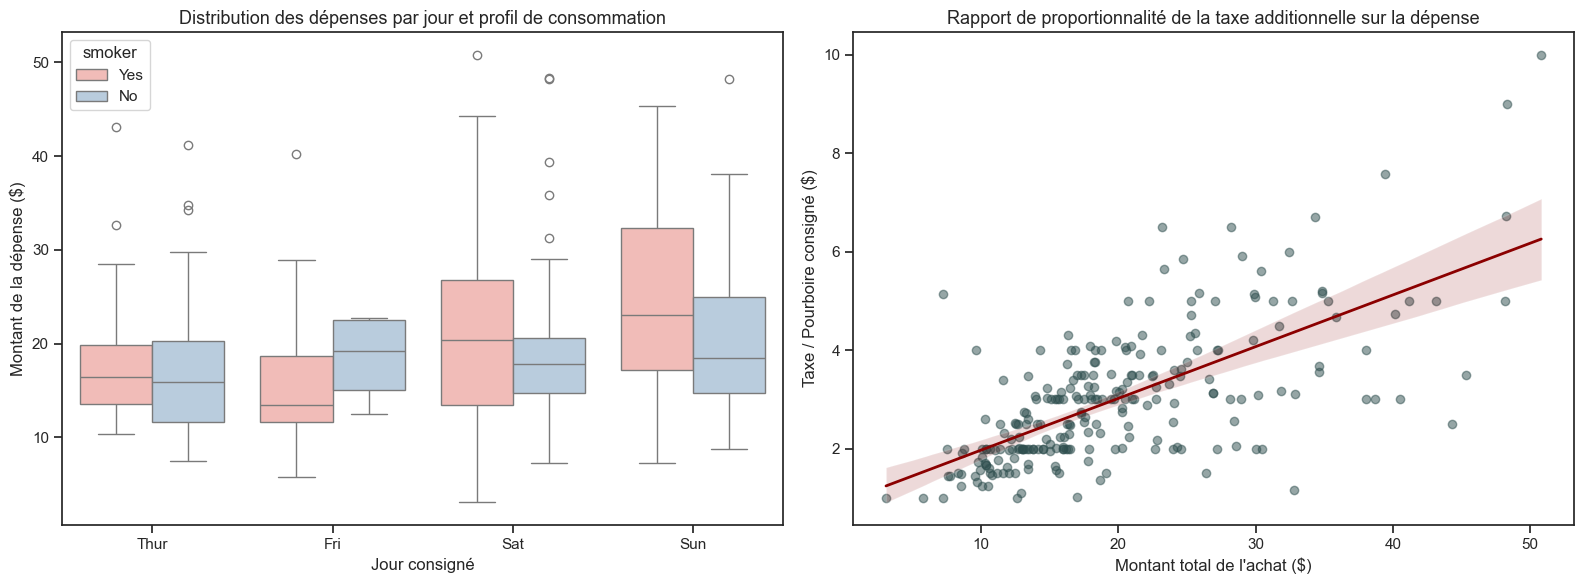

In [12]:
# Analyser la répartition des dépenses selon des variables sociologiques ou temporelles
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Boxplot (Boîte à moustaches) du montant total dépensé selon le jour et la consommation de tabac
sns.boxplot(
    data=df_registre, 
    x='day', 
    y='total_bill', 
    hue='smoker', 
    palette='Pastel1', 
    ax=ax[0]
)
ax[0].set_title("Distribution des dépenses par jour et profil de consommation", fontsize=13)
ax[0].set_xlabel("Jour consigné")
ax[0].set_ylabel("Montant de la dépense ($)")

# Graphique 2 : Nuage de points avec régression pour évaluer la proportionnalité de la taxe/pourboire par rapport à la dépense
sns.regplot(
    data=df_registre, 
    x='total_bill', 
    y='tip', 
    scatter_kws={'alpha':0.5, 'color':'darkslategrey'},
    line_kws={'color':'darkred', 'linewidth':2},
    ax=ax[1]
)
ax[1].set_title("Rapport de proportionnalité de la taxe additionnelle sur la dépense", fontsize=13)
ax[1].set_xlabel("Montant total de l'achat ($)")
ax[1].set_ylabel("Taxe / Pourboire consigné ($)")

plt.tight_layout()
plt.show()

# EXERCICE 2
À partir du même registre `df_registre`, générez un **Violin Plot** (`sns.violinplot`) pour observer la densité de répartition des taxes/pourboires (`tip`) selon le moment du service (`time`, à savoir le repas du midi ou du soir).
Utilisez le paramètre `hue='sex'` pour analyser visuellement si le genre de la personne enregistrée influe sur la structure des sommes versées.

In [7]:
# Votre code ici

## Partie 3 : Démographie historique, structures et Discrétisation

En histoire, les données brutes numériques gagnent à être classées. Tout comme on découpe l'espace en zones ou en classes de densité, on découpe les variables quantitatives continues (des âges d'individus, des niveaux de fortune) en **catégories historiques** (ex: tranches d'âges démographiques, strates fiscales) grâce à la méthode `.cut()` de pandas.

In [13]:
# Chargement d'une base de données nominative historique célèbre : la liste des passagers du Titanic
df_passagers = sns.load_dataset('titanic')

# Nettoyage des données pour l'exercice (conservation des individus dont l'âge est connu)
df_passagers = df_passagers.dropna(subset=['age']).copy()

# Discrétisation : Définition de catégories d'âges pertinentes pour l'analyse démographique de l'époque
seuils_ages = [0, 12, 18, 35, 55, 100]
categories_historiques = ['Enfant', 'Adolescent', 'Adulte jeune', 'Adulte mûr', 'Vieillard / Senior']

df_passagers['categorie_demographique'] = pd.cut(
    df_passagers['age'], 
    bins=seuils_ages, 
    labels=categories_historiques
)

print("Structure de l'échantillon après création des classes démographiques :")
display(df_passagers[['age', 'categorie_demographique', 'class', 'survived']].head(10))

Structure de l'échantillon après création des classes démographiques :


,age,categorie_demographique,class,survived
0,22.0,Adulte jeune,Third,0
1,38.0,Adulte mûr,First,1
2,26.0,Adulte jeune,Third,1
3,35.0,Adulte jeune,First,1
4,35.0,Adulte jeune,Third,0
6,54.0,Adulte mûr,First,0
7,2.0,Enfant,Third,0
8,27.0,Adulte jeune,Third,1
9,14.0,Adolescent,Second,1
10,4.0,Enfant,Third,1


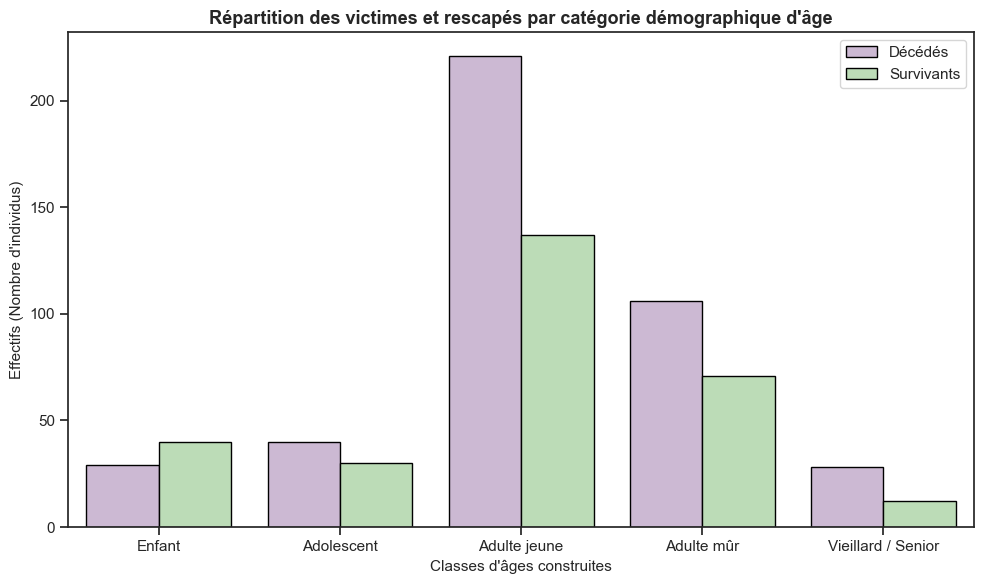

In [14]:
# Visualisation de la structure démographique des survivants avec Seaborn
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=df_passagers, 
    x='categorie_demographique', 
    hue='survived', 
    palette='PRGn', # Palette divergente 
    edgecolor='black', 
    ax=ax
)

ax.set_title("Répartition des victimes et rescapés par catégorie démographique d'âge", fontsize=13, fontweight='bold')
ax.set_xlabel("Classes d'âges construites", fontsize=11)
ax.set_ylabel("Effectifs (Nombre d'individus)", fontsize=11)
ax.legend(['Décédés', 'Survivants'], loc='upper right')

plt.tight_layout()
plt.show()

# EXERCICE DE SYNTHÈSE / CAS PRATIQUE (30 minutes)
Vous travaillez sur un registre de recrutement militaire du XIXe siècle (ou un rôle de taxe de capitation). Ce document répertorie la taille (ou l'indice anthropométrique) des conscrits, leur statut d'alphabétisation, et le montant de l'impôt ou de la taxe d'exemption payée par leur famille.

**Objectifs de l'exercice :**
1. Prenez connaissance de la base de données simulée ci-dessous.
2. À l'aide de la méthode `pd.cut()`, discrétisez la colonne anthropométrique de la taille (`hauteur_cm`) en 4 catégories historiques d'aptitude militaire :
   - Moins de 155 cm : 'Inapte (Réformé)'
   - 155 à 165 cm : 'Aptitude Infanterie'
   - 165 à 175 cm : 'Aptitude Ligne / Standard'
   - 175 cm et plus : 'Aptitude Élite (Grenadiers/Cavalerie)'
3. Produisez une figure Matplotlib propre contenant deux axes (1 ligne, 2 colonnes) :
   - **Axe 0 (Seaborn)** : Un graphique d'effectifs (`sns.countplot`) présentant le nombre de conscrits dans chaque classe d'aptitude physique.
   - **Axe 1 (Seaborn)** : Un graphique (`sns.boxplot` ou `sns.scatterplot`) croisant ces classes d'aptitude avec le montant des taxes d'exemption versées par les familles (`taxes_exemption`), en séparant selon le statut d'alphabétisation (`sait_lire`).

In [15]:
# Code générant le registre simulé des conscrits pour l'exercice
np.random.seed(1815)
n_conscrits = 250
registre_conscrits = pd.DataFrame({
    'matricule': range(1, n_conscrits + 1),
    'hauteur_cm': np.random.normal(166, 7, n_conscrits), # Taille moyenne mesurée au XIXe s.
    'sait_lire': np.random.choice(['Oui', 'Non'], n_conscrits, p=[0.4, 0.6]),
})
# Simulation de taxes d'exemption liées à la fortune sociale indirecte (ici corrélée à l'alphabétisation)
registre_conscrits['taxes_exemption'] = (
    (registre_conscrits['sait_lire'] == 'Oui').astype(int) * 300 + 
    np.random.exponential(150, n_conscrits)
)

print("Extrait du registre de conscription prêt pour l'analyse :")
display(registre_conscrits.head())

Extrait du registre de conscription prêt pour l'analyse :


,matricule,hauteur_cm,sait_lire,taxes_exemption
0,1,163.760283,Non,9.771616
1,2,158.238155,Oui,415.152415
2,3,161.674747,Non,24.863099
3,4,169.102507,Non,1.336933
4,5,170.899881,Non,80.049434


In [16]:
# Votre code de résolution ici